## Improved Models for 2h and 4h time horizons

### Import Libraries

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)



### Load Data and data checks

In [42]:
flights_2h = pd.read_csv("combined_data_2h.csv")
print("2h dataset shape:", flights_2h.shape)
flights_2h.head()

2h dataset shape: (335918, 32)


,date,scheduled_dep_dt,actual_dep_dt,carrier_code,destination_airport,scheduled_elapsed_time_minutes,year,month,day_of_week,is_weekend,...,dew_point_temperature,relative_humidity,altimeter,aircraft_age,week_num,temperature_dewpoint_spread,airport_delay_average_1h,airport_delay_stddev_1h,airport_departures_observed_1h,departure_delay_minutes
0,2022-01-01,2022-01-01 05:25:00,2022-01-01 05:25:00,WN,DEN,145.0,2022.0,1.0,5.0,1,...,4.4,71.0,1014.2,16.0,1,5.0,0.0,0.0,0.0,0.0
1,2022-01-01,2022-01-01 05:55:00,2022-01-01 05:52:00,DL,SLC,118.0,2022.0,1.0,5.0,1,...,4.4,71.0,1014.2,3.0,1,5.0,0.0,0.0,0.0,-3.0
2,2022-01-01,2022-01-01 06:00:00,2022-01-01 06:14:00,DL,ATL,272.0,2022.0,1.0,5.0,1,...,5.0,74.0,1014.6,20.0,1,4.4,0.0,0.0,0.0,14.0
3,2022-01-01,2022-01-01 06:02:00,2022-01-01 05:56:00,UA,LAX,98.0,2022.0,1.0,5.0,1,...,5.0,74.0,1014.6,6.0,1,4.4,0.0,0.0,0.0,-6.0
4,2022-01-01,2022-01-01 06:10:00,2022-01-01 07:51:00,DL,MSP,218.0,2022.0,1.0,5.0,1,...,5.0,74.0,1014.6,24.0,1,4.4,0.0,0.0,0.0,101.0


In [4]:
flights_2h.info()
flights_2h["outcome"].value_counts(
    dropna=False
).sort_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335918 entries, 0 to 335917
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   date                            335918 non-null  object 
 1   scheduled_dep_dt                335918 non-null  object 
 2   actual_dep_dt                   335918 non-null  object 
 3   carrier_code                    335918 non-null  object 
 4   destination_airport             335918 non-null  object 
 5   scheduled_elapsed_time_minutes  335918 non-null  float64
 6   year                            335918 non-null  float64
 7   month                           335918 non-null  float64
 8   day_of_week                     335918 non-null  float64
 9   is_weekend                      335918 non-null  int64  
 10  sched_dep_hour                  335918 non-null  float64
 11  outcome                         335918 non-null  float64
 12  days_until_holid

outcome
0.0    205566
1.0    108210
2.0     13475
3.0      4338
4.0      1700
5.0       751
6.0       398
7.0       575
8.0       905
Name: count, dtype: int64

In [5]:
#converting date column to datetime
flights_2h["date"] = pd.to_datetime(flights_2h["date"], errors="coerce")

In [6]:
#Chronological sort
flights_2h = (flights_2h 
    .sort_values("date")
    .reset_index(drop=True))

In [7]:
#Verifying the sort
print("Earliest date:", flights_2h["date"].min())
print("Latest date:", flights_2h["date"].max())

Earliest date: 2022-01-01 00:00:00
Latest date: 2026-04-30 00:00:00


In [9]:
#verifying target and converting outcomes to integer
flights_2h["outcome"] = flights_2h["outcome"].astype(int)

print("Target datatype:", flights_2h["outcome"].dtype)

print("Missing target values:", flights_2h["outcome"].isna().sum())

print("Outcome classes:", sorted(flights_2h["outcome"].dropna().unique()))

Target datatype: int64
Missing target values: 0
Outcome classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]


### Feature Selection

In [10]:
#feature selection
numeric_features_2h = [
    "scheduled_elapsed_time_minutes",
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "sched_dep_hour",
    "days_until_holiday",
    "days_from_holiday",
    "year_mfr",
    "no_seats",
    "visibility",
    "ceiling_height",
    "wind_speed",
    "wind_direction",
    "temperature",
    "dew_point_temperature",
    "relative_humidity",
    "altimeter",
    "aircraft_age",
    "week_num",
    "temperature_dewpoint_spread",
    "airport_delay_average_1h",
    "airport_delay_stddev_1h",
    "airport_departures_observed_1h"
]

In [11]:
categorical_features_2h = [
    "carrier_code",
    "destination_airport",
    "model"
]

In [12]:
features_2h = (numeric_features_2h + categorical_features_2h)
target_2h = "outcome"

In [16]:
#verifying columns exist
missing_features_2h = [
    column
    for column in features_2h
    if column not in flights_2h.columns]
print("Missing features:", missing_features_2h)

Missing features: []


### Data Splits

In [17]:
train_2h = flights_2h[flights_2h["date"] < "2024-01-01"].copy()

validation_2h = flights_2h[(flights_2h["date"] >= "2024-01-01") & (flights_2h["date"] < "2025-01-01")].copy()

test_2h = flights_2h[flights_2h["date"] >= "2025-01-01"].copy()

In [19]:
print("2h training rows:", len(train_2h))
print("2h validation rows:", len(validation_2h))
print("2h test rows:", len(test_2h))

2h training rows: 151962
2h validation rows: 84932
2h test rows: 99024


In [20]:
#verifying data ranges
print("Train:", train_2h["date"].min(), "-", train_2h["date"].max())

print(
    "Validation:", validation_2h["date"].min(), "-", validation_2h["date"].max())

print("Test:", test_2h["date"].min(), "-", test_2h["date"].max())

Train: 2022-01-01 00:00:00 - 2023-12-31 00:00:00
Validation: 2024-01-01 00:00:00 - 2024-12-31 00:00:00
Test: 2025-01-01 00:00:00 - 2026-04-30 00:00:00


### Defining the input and output features

In [21]:
X_train_2h = train_2h[features_2h].copy()
y_train_2h = train_2h[target_2h].copy()

X_validation_2h = validation_2h[features_2h].copy()
y_validation_2h = validation_2h[target_2h].copy()

X_test_2h = test_2h[features_2h].copy()
y_test_2h = test_2h[target_2h].copy()

### preprocessing


In [23]:
numeric_transformer_2h = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])

In [24]:
categorical_transformer_2h = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))])

In [25]:
preprocessor_2h = ColumnTransformer([("numeric", numeric_transformer_2h, numeric_features_2h), ("categorical", categorical_transformer_2h, categorical_features_2h)])

In [26]:
#only fitting on training data
X_train_2h_processed = (preprocessor_2h.fit_transform(X_train_2h))

X_validation_2h_processed = (preprocessor_2h.transform(X_validation_2h))

X_test_2h_processed = (preprocessor_2h.transform(X_test_2h))

/Users/anushkagadodia/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/anushkagadodia/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [28]:
print("Processed training shape:", X_train_2h_processed.shape)
print("Processed validation shape:", X_validation_2h_processed.shape)
print("Processed test shape:", X_test_2h_processed.shape)

Processed training shape: (151962, 170)
Processed validation shape: (84932, 170)
Processed test shape: (99024, 170)


### Random Forest Classifier for 2h dataset

In [43]:
rf_model_2h = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1)

In [44]:
#training the model
rf_model_2h.fit(X_train_2h_processed, y_train_2h)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [45]:
#predictions!!
train_predictions_2h = rf_model_2h.predict(X_train_2h_processed)
validation_predictions_2h = rf_model_2h.predict(X_validation_2h_processed)
test_predictions_2h = rf_model_2h.predict(X_test_2h_processed)

In [46]:
#train, val, and test accuract
train_accuracy_2h = accuracy_score(y_train_2h, train_predictions_2h)
validation_accuracy_2h = accuracy_score(y_validation_2h, validation_predictions_2h)
test_accuracy_2h = accuracy_score(y_test_2h,test_predictions_2h)

print(f"2-Hour Training Accuracy: {train_accuracy_2h}")
print(f"2-Hour Validation Accuracy: {validation_accuracy_2h}")
print(f"2-Hour Test Accuracy: {test_accuracy_2h}")

print("Training-validation difference:", abs(train_accuracy_2h - validation_accuracy_2h))

2-Hour Training Accuracy: 0.7891446545846988
2-Hour Validation Accuracy: 0.5687844393161589
2-Hour Test Accuracy: 0.5757089190499273
Training-validation difference: 0.22036021526854


In [47]:
validation_balanced_accuracy_2h = (balanced_accuracy_score(y_validation_2h, validation_predictions_2h))
test_balanced_accuracy_2h = (balanced_accuracy_score(y_test_2h, test_predictions_2h))

print("2-Hour Validation Balanced Accuracy:", validation_balanced_accuracy_2h)
print("2-Hour Test Balanced Accuracy:", test_balanced_accuracy_2h)

2-Hour Validation Balanced Accuracy: 0.14292693469806206
2-Hour Test Balanced Accuracy: 0.14362544829724308


In [48]:
#Classification
class_labels = [
    "No delay / Early",
    "< 1 hour",
    "1–2 hours",
    "2–3 hours",
    "3–4 hours",
    "4–5 hours",
    "5–6 hours",
    "> 6 hours",
    "Cancelled"
]

In [49]:
print(classification_report(
        y_test_2h,
        test_predictions_2h,
        labels=list(range(9)),
        target_names=class_labels,
        zero_division=0))

                  precision    recall  f1-score   support

No delay / Early       0.75      0.64      0.69     63389
        < 1 hour       0.39      0.57      0.47     28909
       1–2 hours       0.11      0.09      0.10      4042
       2–3 hours       0.05      0.00      0.01      1350
       3–4 hours       0.00      0.00      0.00       523
       4–5 hours       0.00      0.00      0.00       246
       5–6 hours       0.00      0.00      0.00       107
       > 6 hours       0.00      0.00      0.00       163
       Cancelled       0.00      0.00      0.00       295

        accuracy                           0.58     99024
       macro avg       0.14      0.14      0.14     99024
    weighted avg       0.60      0.58      0.58     99024



### Confusion Matrix

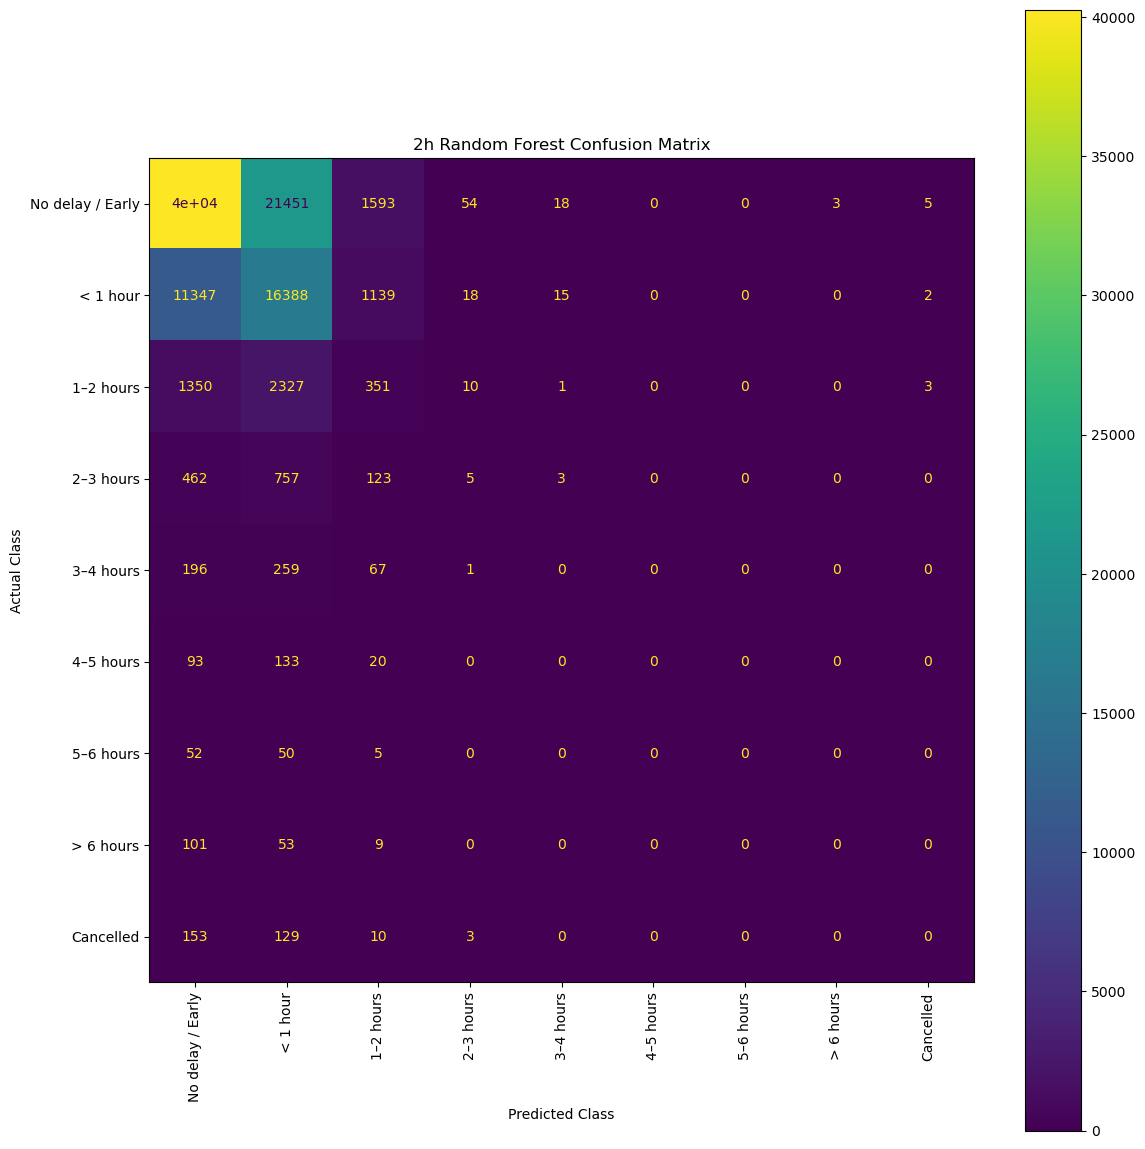

In [50]:
fig, ax = plt.subplots(figsize=(12, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test_2h,
    test_predictions_2h,
    labels=list(range(9)),
    display_labels=class_labels,
    xticks_rotation=90,
    ax=ax)

plt.title("2h Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()